# Task 5: Exploratory Data Analysis

**Objective:** Identify patterns, relationships, trends, and anomalies using statistical analysis and visualizations.

**Tools:** Python, Pandas, Matplotlib, Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [3]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-nu

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9994.0,NaN,NaN,NaN,4997.5,2885.163629,1.0,2499.25,4997.5,7495.75,9994.0
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,1237,9/5/2016,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9994,1334,12/16/2015,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.nunique().sort_values()

,0
Country,1
Segment,3
Category,3
Ship Mode,4
Region,4
Discount,12
Quantity,14
Sub-Category,17
State,49
City,531


In [7]:
print("Duplicate rows:", df.duplicated().sum())

missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
}).sort_values("Missing Values", ascending=False)


Duplicate rows: 0


,Missing Values,Percentage
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Customer Name,0,0.0
Segment,0,0.0
Country,0,0.0
City,0,0.0


In [8]:
df = df.drop_duplicates()

### Observation

- The dataset contains 9,994 rows and 21 columns.
- It includes both numerical and categorical features.
- Sales, Profit, Quantity, and Discount are the main numerical variables.

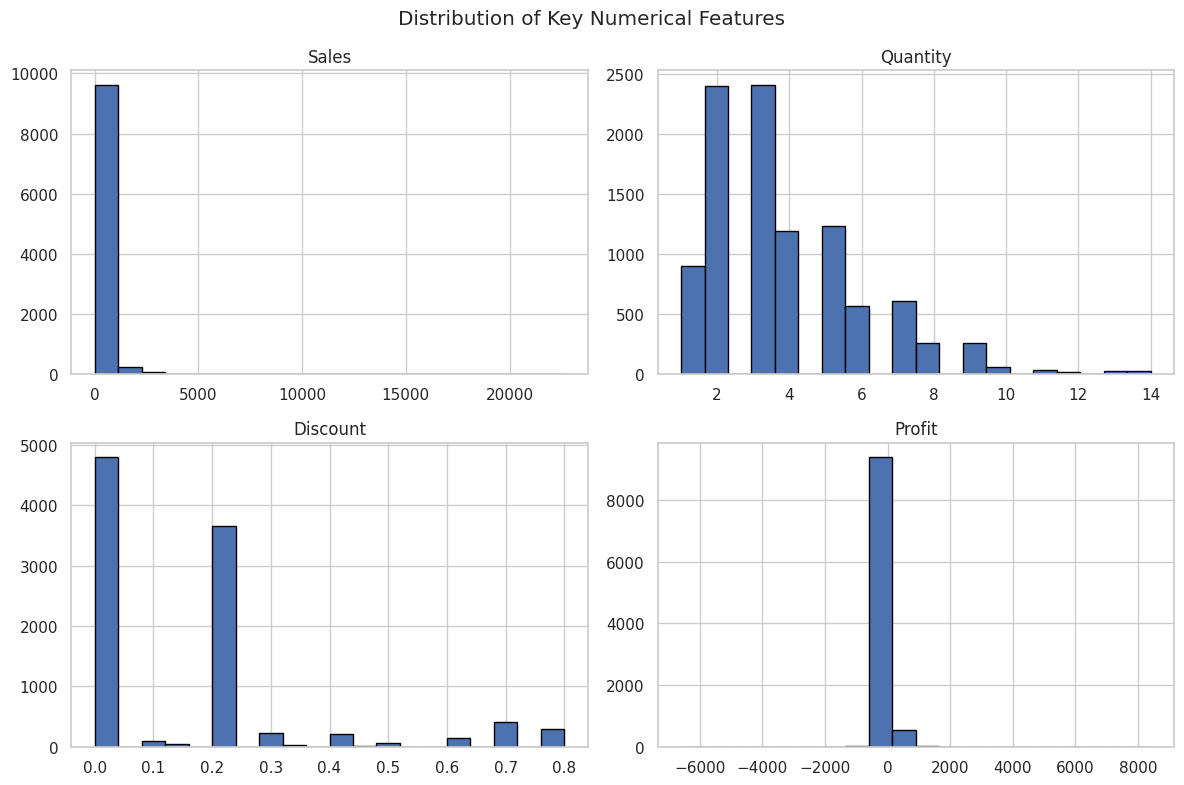

In [22]:
numeric_columns = ['Sales', 'Quantity', 'Discount', 'Profit']

df[numeric_columns].hist(
    figsize=(12,8),
    bins=20,
    edgecolor='black'
)

plt.suptitle('Distribution of Key Numerical Features')
plt.tight_layout()
plt.show()

### Observation

- Sales distribution is right-skewed, indicating that most orders have low sales while a few orders have very high sales.
- Profit shows significant variation, with some transactions resulting in losses.
- Most orders contain small quantities of products.
- Discounts are generally low, with higher discounts occurring less frequently.

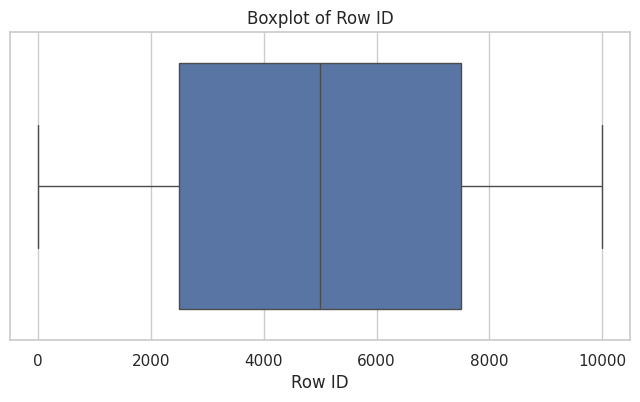

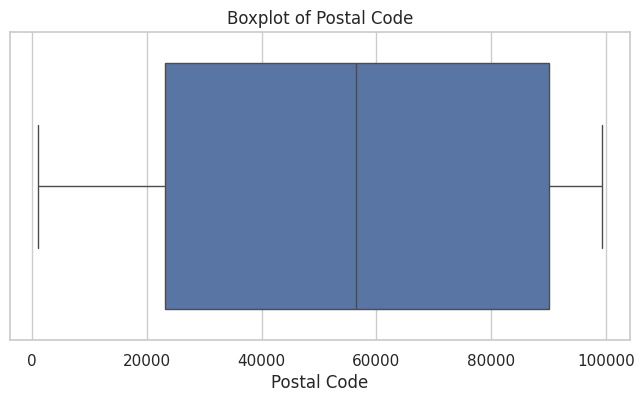

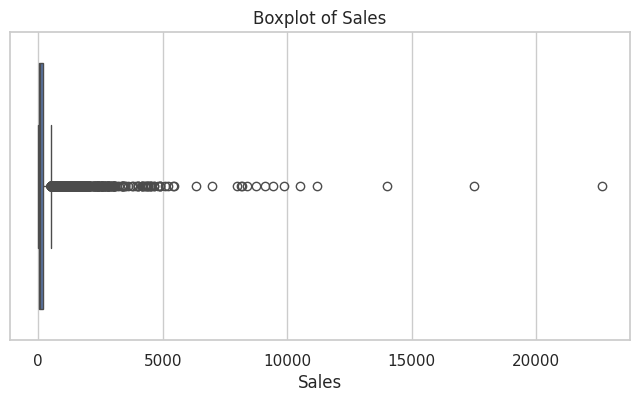

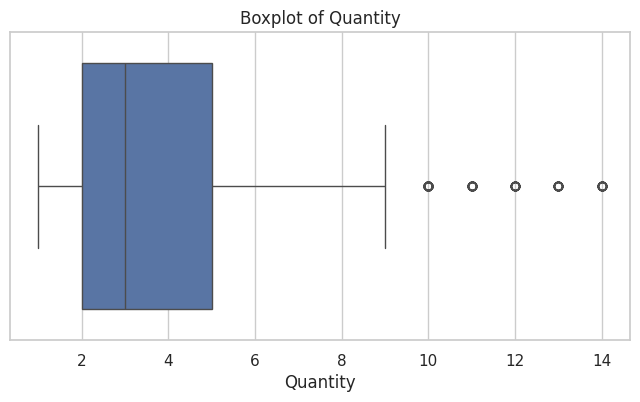

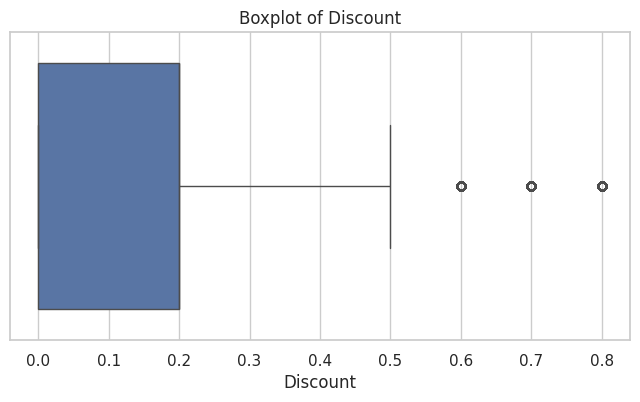

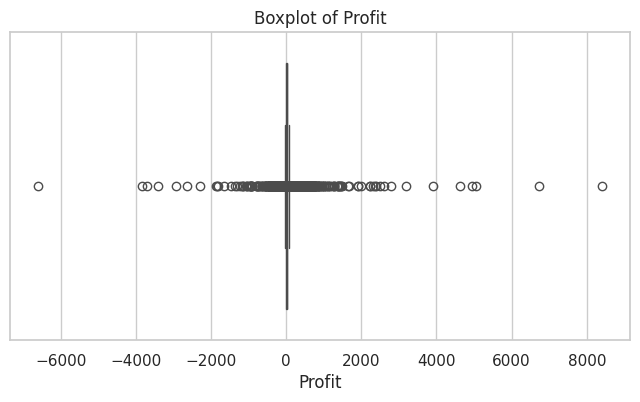

In [10]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

### Observation

- Sales contains a large number of outliers, indicating a few exceptionally high-value transactions compared to the majority of orders.
- Quantity shows a small number of outliers, suggesting that only a few orders involve unusually large quantities.
- Discount contains several high-value outliers (60%, 70%, and 80%), indicating that large discounts are offered infrequently.
- Most orders have relatively low sales values, moderate quantities, and discounts below 20%.
- Row ID and Postal Code are identifier fields and do not provide meaningful business insights for outlier analysis.
- The presence of outliers in Sales, Quantity, and Discount should be considered during further analysis and predictive modeling.

In [11]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

for column in categorical_columns:
    print(f"\nValue counts for {column}:")
    display(df[column].value_counts().head(10))


Value counts for Order ID:


,count
Order ID,
CA-2017-100111,14
CA-2017-157987,12
CA-2016-165330,11
US-2016-108504,11
US-2015-126977,10
CA-2016-105732,10
CA-2015-131338,10
CA-2015-158421,9
CA-2014-106439,9



Value counts for Order Date:


,count
Order Date,
9/5/2016,38
9/2/2017,36
11/10/2016,35
12/1/2017,34
12/2/2017,34
12/9/2017,33
11/12/2017,30
12/8/2017,30
9/9/2017,29



Value counts for Ship Date:


...

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847



Value counts for Sub-Category:


,count
Sub-Category,
Binders,1523
Paper,1370
Furnishings,957
Phones,889
Storage,846
Art,796
Accessories,775
Chairs,617
Appliances,466



Value counts for Product Name:


,count
Product Name,
Staple envelope,48
Staples,46
Easy-staple paper,46
Avery Non-Stick Binders,20
Staples in misc. colors,19
KI Adjustable-Height Table,18
Staple remover,18
Storex Dura Pro Binders,17
Staple-based wall hangings,16


### Observation

- Standard Class is the most frequently used shipping mode, indicating that customers generally prefer economical shipping options.
- The Consumer segment represents the largest customer group, followed by Corporate and Home Office segments.
- All records belong to the United States, making this a single-country dataset.
- New York City and Los Angeles have the highest number of orders among all cities.
- California, New York, and Texas contribute the largest number of orders among states.
- The West region contains the highest number of transactions, followed by the East region.
- Office Supplies is the most frequently purchased product category.
- Binders, Paper, Furnishings, and Phones are among the most commonly ordered sub-categories.
- Customer purchasing activity is concentrated among a few customers, products, cities, and regions.

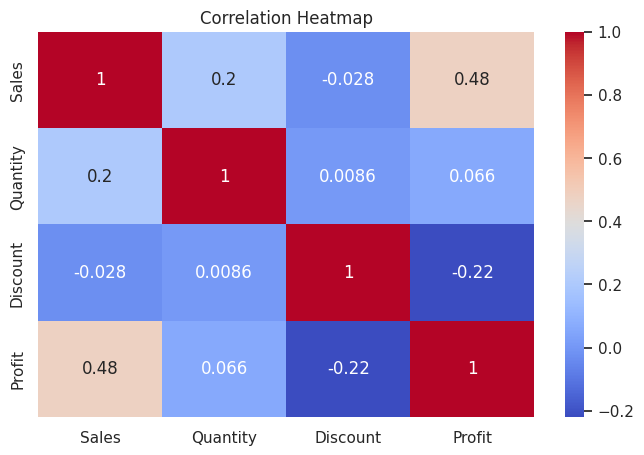

In [23]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Sales','Quantity','Discount','Profit']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

### Observation

- Sales and Profit show a moderate positive correlation (0.48), indicating that higher sales generally contribute to higher profits.
- Discount has a moderate negative correlation with Profit (-0.22), suggesting that larger discounts tend to reduce profitability.
- Sales and Quantity have a weak positive correlation (0.20), meaning that larger order quantities contribute somewhat to increased sales.
- Quantity has a very weak relationship with Profit (0.07), indicating that profit depends more on sales value and discount strategy than on quantity alone.
- Overall, Sales and Discount are the most influential factors affecting Profit in this dataset.

In [14]:
for col in df.columns:
    print(col)

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit


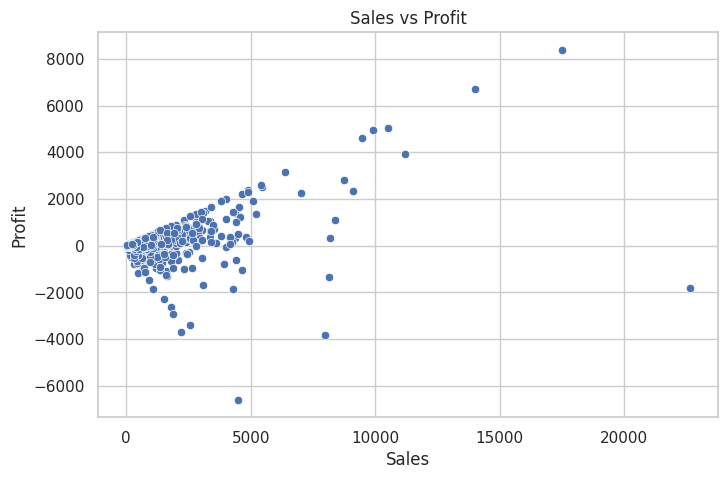

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Sales', y='Profit')
plt.title('Sales vs Profit')
plt.show()

### Observation

- Sales and Profit show a generally positive relationship, indicating that higher sales often lead to higher profits.
- Most orders are concentrated in the lower sales range (below 5,000).
- Several high-sales transactions generate substantial profits, reaching over 8,000.
- A few orders with high sales still result in negative profits, suggesting the impact of discounts, costs, or other business factors.
- The presence of both high-profit and high-loss outliers indicates significant variation in order profitability.

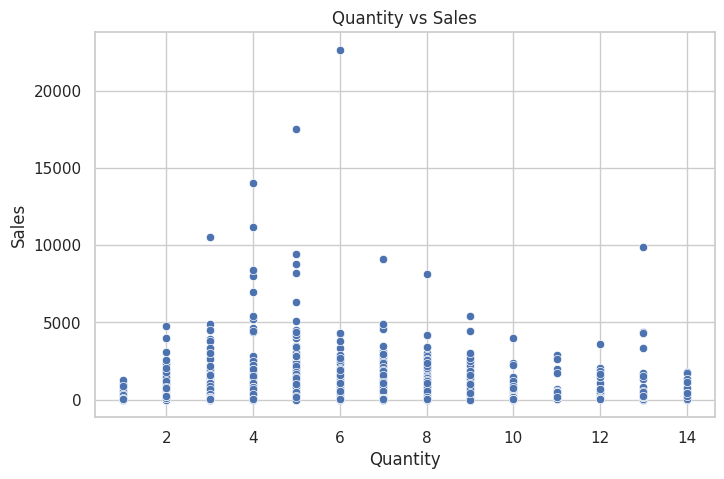

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Quantity', y='Sales')
plt.title('Quantity vs Sales')
plt.show()

### Observation

- Sales generally increase with quantity ordered.
- Most orders involve small quantities with moderate sales.
- A few high-sales outliers are present across different quantity levels.

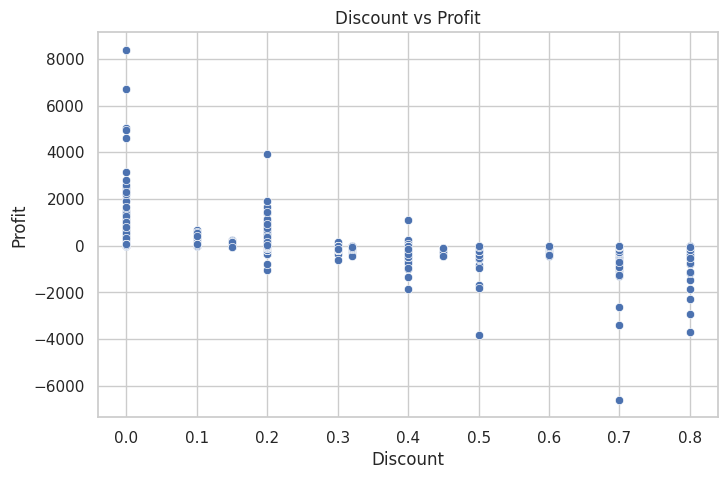

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title('Discount vs Profit')
plt.show()

### Observation

- Profit decreases as discount increases.
- Higher discounts are often associated with lower or negative profits.
- Excessive discounting can significantly impact profitability.

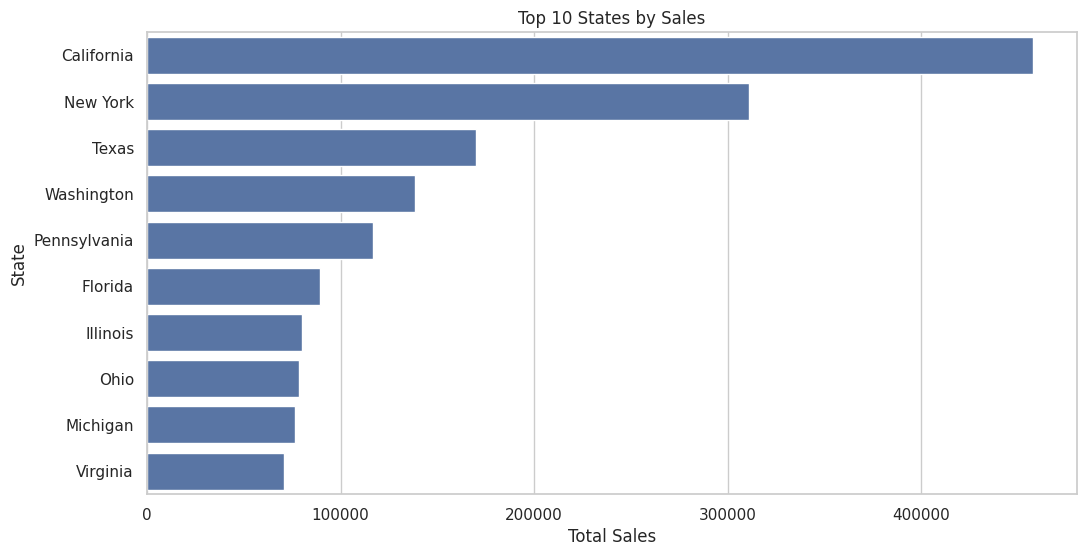

In [18]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title('Top 10 States by Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.show()

### Observation

- California generates the highest sales, followed by New York and Texas.
- Sales are concentrated in a few top-performing states.
- California significantly outperforms all other states in total sales.

### Observation

California generated the highest sales among all states, followed by New York and Texas. A small number of states contribute a significant portion of total revenue.

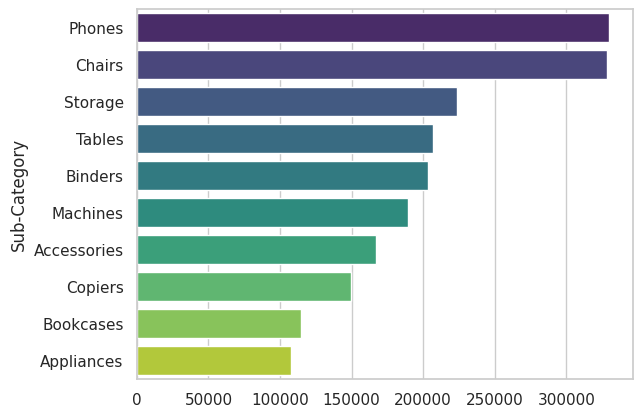

In [27]:
sns.barplot(
    x=top_sub.values,
    y=top_sub.index,
    hue=top_sub.index,
    palette='viridis',
    legend=False
)
plt.show()


### Observation

- Phones and Chairs are the highest revenue-generating sub-categories.
- Storage, Tables, and Binders also contribute significantly to total sales.
- Sales are concentrated among a few key product sub-categories.

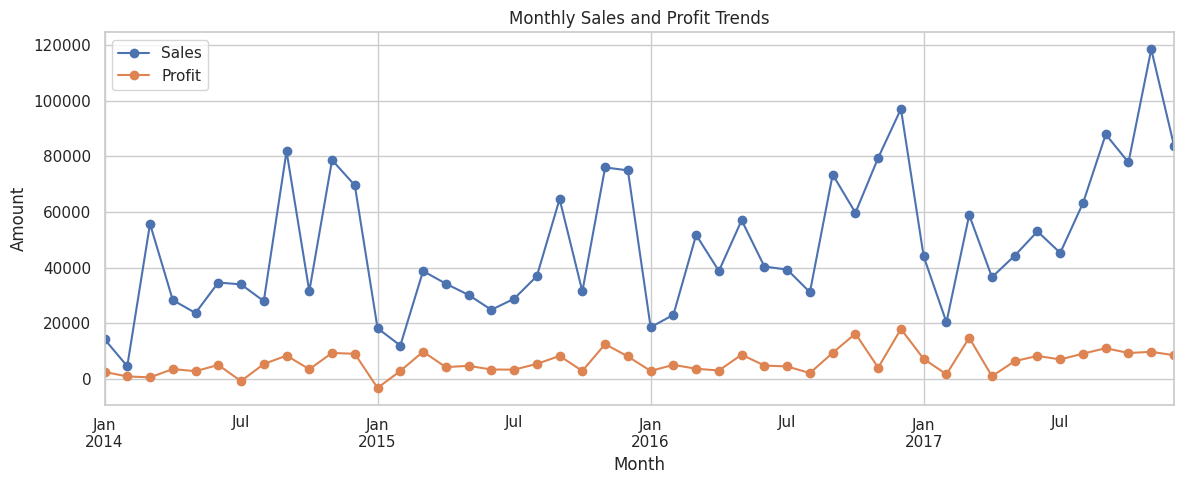

In [24]:
# Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Calculate monthly sales and profit
monthly = (
    df.set_index('Order Date')
      .resample('ME')[['Sales', 'Profit']]
      .sum()
)

# Plot monthly trends
monthly.plot(figsize=(12, 5), marker='o')

plt.title('Monthly Sales and Profit Trends')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend(['Sales', 'Profit'])
plt.tight_layout()
plt.show()

### Observation

- Monthly sales fluctuate throughout the analysed period.
- Sales generally increase toward the final months of each year.
- Profit follows the sales trend in several months, but high sales do not always produce proportionally high profits.
- Some months show weaker profitability, which may be related to discounts, product mix, or operating costs.

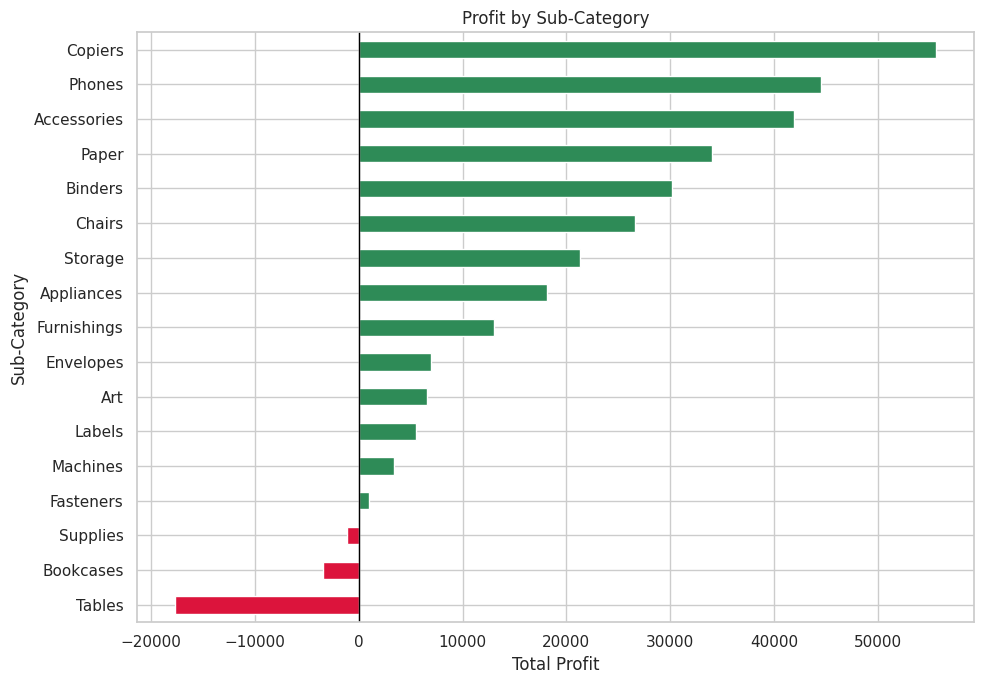

In [25]:
subcategory_profit = (
    df.groupby('Sub-Category')['Profit']
      .sum()
      .sort_values()
)

colors = [
    'crimson' if profit < 0 else 'seagreen'
    for profit in subcategory_profit
]

plt.figure(figsize=(10, 7))
subcategory_profit.plot(kind='barh', color=colors)

plt.title('Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

### Observation

- Copiers generate the highest total profit, followed by Phones and Accessories.
- Tables produce the largest overall loss despite generating high sales.
- Bookcases and Supplies also show negative profitability.
- High sales do not always result in high profit.
- Loss-making sub-categories may require changes to pricing, discounts, or operating costs.

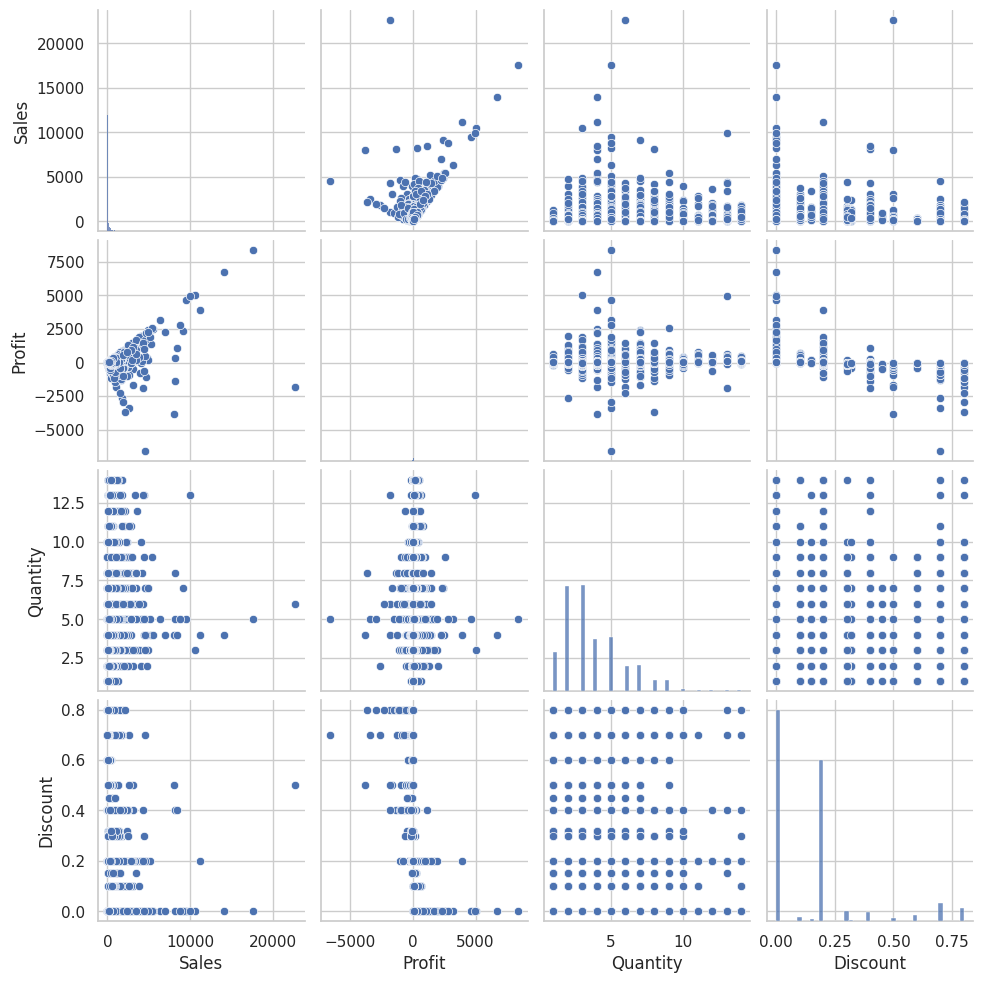

In [20]:
selected_columns = ['Sales', 'Profit', 'Quantity', 'Discount']

sns.pairplot(df[selected_columns])
plt.show()

### Observation

- Sales and Profit show a positive relationship.
- Higher discounts are generally associated with lower profits.
- Quantity has a weak relationship with both Sales and Profit.
- A few outliers are visible in Sales and Profit.

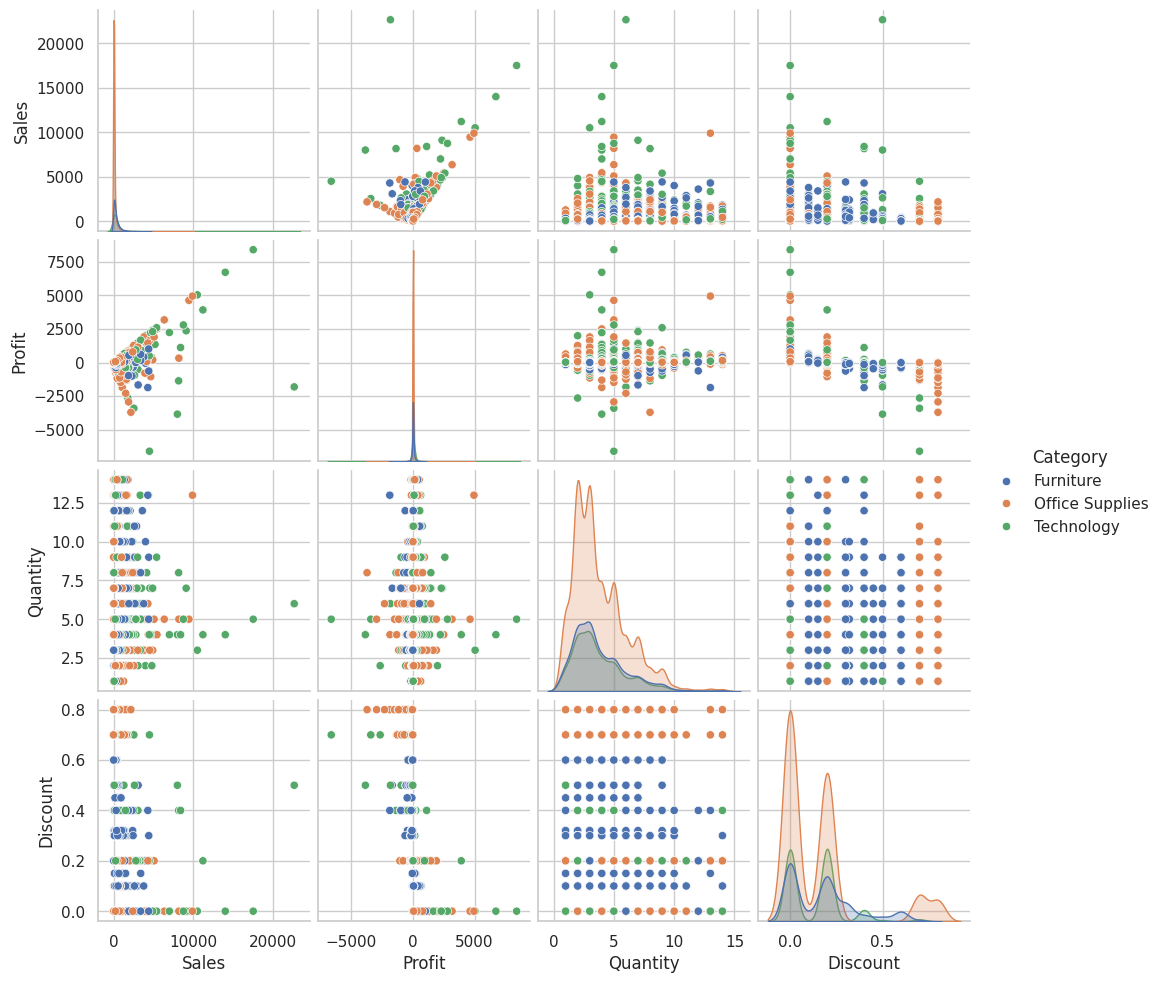

In [21]:
sns.pairplot(
    df[['Sales','Profit','Quantity','Discount','Category']],
    hue='Category'
)
plt.show()

### Observation

- Technology generates the highest sales and profits.
- Office Supplies have the largest number of transactions.
- Higher discounts tend to reduce profitability.
- Several outliers are present across categories.

## Final Findings

1. The dataset contains 9,994 rows and 21 columns.

2. No missing values were found in the dataset.

3. The strongest relationship is between Sales and Profit (correlation = 0.48).

4. The most important trend identified is that higher discounts tend to reduce profitability, while Technology products generate the highest sales and profits.

5. Possible anomalies or outliers occur in Sales, Profit, Quantity, and Discount.

6. These results may help with business decision-making, sales optimization, and profit improvement strategies.

## Key Insights

1. Technology category generates the highest sales and profit.
2. California is the top-performing state in terms of sales.
3. Phones and Chairs are the highest revenue-generating sub-categories.
4. Higher discounts negatively impact profitability.
5. Sales and Profit show a moderate positive relationship.

## Recommendations

1. Focus on high-performing categories such as Technology.
2. Monitor discount strategies to prevent profit loss.
3. Increase marketing efforts in top-performing states.
4. Prioritize high-revenue sub-categories such as Phones and Chairs.

## Conclusion

This Exploratory Data Analysis (EDA) identified key sales trends, profitability patterns, customer preferences, and regional performance differences within the Superstore dataset. The findings show that Technology products, California, and top-performing sub-categories contribute significantly to revenue. Additionally, higher discounts were found to negatively impact profitability. These insights can support data-driven business decisions and future predictive analytics initiatives.